# 57 - 大規模顔検索: pyconjp 23,628枚での人物検索

pyconjp アーカイブ（62イベント、23,628枚）を対象に顔検出 + Embedding を行い、
terada を年代を超えて検索する。

## 入力
- `data/hdd-images/pyconjp/` (62イベント、23,628枚)
- `data/images.duckdb` (terada の顔 Embedding)

## 出力
- pyconjp 全画像の顔 Embedding を DuckDB に保存
- terada の年代別検索結果
- HNSW 検索のスケーラビリティ評価

**注意**: この処理は数時間かかる可能性があります。

In [1]:
import json
import re
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from insightface.app import FaceAnalysis
from PIL import Image
from tqdm.notebook import tqdm

2026-02-14 16:31:00.213642122 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
PYCONJP_DIR = Path("../data/hdd-images/pyconjp")
MODEL_NAME = "buffalo_l"
MODEL_FULL_NAME = "insightface/buffalo_l"
EMBEDDING_DIM = 512
COMMIT_INTERVAL = 100

## pyconjp 画像カタログの作成

In [3]:
# pyconjp ディレクトリのスキャン
event_dirs = sorted([d for d in PYCONJP_DIR.iterdir() if d.is_dir()])
print(f"イベント数: {len(event_dirs)}")

# 全画像をリストアップ
pyconjp_images = []
for event_dir in event_dirs:
    event_name = event_dir.name
    # 年を抽出 (例: pycon_jp_2014_day1_tutorial → 2014)
    year_match = re.search(r"(\d{4})", event_name)
    year = int(year_match.group(1)) if year_match else None

    for img_path in sorted(event_dir.iterdir()):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".gif", ".webp", ".bmp"]:
            pyconjp_images.append({
                "id": f"pyconjp_{event_name}_{img_path.name}",
                "file_path": str(img_path),
                "file_name": img_path.name,
                "event": event_name,
                "year": year,
            })

df_pyconjp = pd.DataFrame(pyconjp_images)
print(f"総画像数: {len(df_pyconjp)}")

# 年別・イベント別の画像数
event_stats = df_pyconjp.groupby(["year", "event"]).size().reset_index(name="image_count")
print(f"\nイベント別画像数:")
display(event_stats)

イベント数: 62


総画像数: 23628

イベント別画像数:


,year,event,image_count
0,2011.0,pycon_jp_2011,501
1,2012.0,pycon_jp_2012_day1,644
2,2012.0,pycon_jp_2012_day2,570
3,2012.0,pycon_jp_2012_party,142
4,2012.0,pycon_jp_2012_sprint,193
5,2012.0,pycon_jp_2012_会場下見,103
6,2013.0,pycon_apac_2013_day1,209
7,2013.0,pycon_apac_2013_day2,186
8,2013.0,pycon_apac_2013_sprint,56
9,2014.0,pycon_jp_2014_day1_tutorial,52


## モデルの初期化

In [4]:
print("InsightFace モデルを読み込み中...")
app = FaceAnalysis(name=MODEL_NAME, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))
print("準備完了")

InsightFace モデルを読み込み中...


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
準備完了


## 顔検出 + Embedding 抽出 + DB保存

全画像をバッチ処理し、検出した顔を `face_detections` テーブルに保存する。
中断しても再開できるように、処理済みの画像はスキップする。

In [5]:
conn = duckdb.connect(str(DB_PATH))
conn.execute("LOAD vss;")

# 処理済みの画像IDを取得
processed_ids = set(
    row[0] for row in conn.execute("""
        SELECT DISTINCT image_id FROM face_detections
        WHERE model_name = ? AND image_id LIKE 'pyconjp_%'
    """, [MODEL_FULL_NAME]).fetchall()
)

pending = df_pyconjp[~df_pyconjp["id"].isin(processed_ids)]
print(f"処理済み: {len(processed_ids)} / {len(df_pyconjp)}")
print(f"未処理: {len(pending)}")

処理済み: 0 / 23628
未処理: 23628


In [6]:
total_faces = 0
total_images = 0
errors = 0
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(pending.iterrows(), total=len(pending), desc="pyconjp 顔検出")):
    try:
        img = cv2.imread(row["file_path"])
        if img is None:
            errors += 1
            continue

        faces = app.get(img)
        total_images += 1

        for face in faces:
            face_id = str(uuid.uuid4())
            bbox = face.bbox.astype(float)
            gender = "M" if face.gender == 1 else "F"
            landmark = json.dumps(face.kps.tolist()) if face.kps is not None else None
            embedding = face.normed_embedding.tolist()

            conn.execute("""
                INSERT INTO face_detections
                (face_id, image_id, model_name, bbox_x1, bbox_y1, bbox_x2, bbox_y2,
                 det_score, landmark, age, gender, embedding)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            """, [
                face_id, row["id"], MODEL_FULL_NAME,
                bbox[0], bbox[1], bbox[2], bbox[3],
                float(face.det_score), landmark,
                int(face.age), gender, embedding
            ])
            total_faces += 1

    except Exception as e:
        errors += 1

    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  検出顔数: {total_faces}")
print(f"  エラー数: {errors}")
print(f"  処理時間: {elapsed:.0f} 秒 ({elapsed/60:.1f} 分)")
print(f"  速度: {total_images/elapsed:.1f} 画像/秒")

pyconjp 顔検出:   0%|          | 0/23628 [00:00<?, ?it/s]

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



処理完了:
  処理画像数: 23628
  検出顔数: 74471
  エラー数: 0
  処理時間: 958 秒 (16.0 分)
  速度: 24.7 画像/秒


## HNSW インデックスの再構築

大量のデータが追加されたため、インデックスを再構築する。

In [7]:
conn.execute("SET hnsw_enable_experimental_persistence = true")

try:
    conn.execute("DROP INDEX IF EXISTS face_embedding_idx")
except Exception:
    pass

print("HNSW インデックスを再構築中...")
start = time.time()
conn.execute("""
    CREATE INDEX face_embedding_idx
    ON face_detections
    USING HNSW (embedding)
    WITH (metric = 'cosine')
""")
print(f"完了: {time.time() - start:.1f} 秒")

HNSW インデックスを再構築中...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

完了: 17.6 秒


## 統計確認

In [8]:
# 全体統計
total = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
pyconjp_faces = conn.execute("""
    SELECT COUNT(*) FROM face_detections WHERE image_id LIKE 'pyconjp_%'
""").fetchone()[0]

print(f"face_detections 総レコード数: {total}")
print(f"  うち pyconjp: {pyconjp_faces}")
print(f"  うちオリジナル378枚: {total - pyconjp_faces}")

face_detections 総レコード数: 75162
  うち pyconjp: 74471
  うちオリジナル378枚: 691


## terada 検索: 年代別マッチ結果

In [9]:
# terada の代表 Embedding
terada_emb = conn.execute(f"""
    SELECT f.embedding
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY f.det_score DESC
    LIMIT 1
""").fetchone()[0]

# pyconjp 全体から terada を検索 (Top-100)
search_start = time.time()
results = conn.execute(f"""
    SELECT 
        f.face_id,
        f.image_id,
        f.det_score,
        f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
        array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
    FROM face_detections f
    WHERE f.image_id LIKE 'pyconjp_%'
    ORDER BY distance
    LIMIT 100
""", [[float(x) for x in terada_emb]]).fetchdf()
search_time = time.time() - search_start

results["similarity"] = 1.0 - results["distance"]

# image_id からイベント名と年を抽出
results["event"] = results["image_id"].str.extract(r"pyconjp_(.+?)_[^_]+$")[0]
results["year"] = results["event"].str.extract(r"(\d{4})").astype(float)

print(f"検索時間: {search_time:.3f} 秒 ({pyconjp_faces} 顔ベクトルに対して)")
print(f"\nTop-20 マッチ:")
display(results[["image_id", "event", "year", "similarity", "det_score"]].head(20))

検索時間: 0.118 秒 (74471 顔ベクトルに対して)

Top-20 マッチ:


,image_id,event,year,similarity,det_score
0,pyconjp_pycon_apac_2023_day_2_53297736134.jpg,pycon_apac_2023_day_2,2023.0,0.821029,0.845958
1,pyconjp_pycon_apac_2023_day_2_53300519548.jpg,pycon_apac_2023_day_2,2023.0,0.817517,0.853716
2,pyconjp_pycon_jp_2024_conference_day1_54039452...,pycon_jp_2024_conference_day1,2024.0,0.810161,0.813146
3,pyconjp_pycon_jp_2024_conference_day1_54039783...,pycon_jp_2024_conference_day1,2024.0,0.794392,0.847611
4,pyconjp_pycon_us_2025_参加報告会_54653191879.jpg,pycon_us_2025_参加報告会,2025.0,0.792256,0.907620
5,pyconjp_pycon_jp_2018_conference_day_2_4510400...,pycon_jp_2018_conference_day_2,2018.0,0.788496,0.872848
6,pyconjp_pycon_apac_2013_day1_9894537854.jpg,pycon_apac_2013_day1,2013.0,0.779250,0.915165
7,pyconjp_pycon_apac_2023_day_2_53297736139.jpg,pycon_apac_2023_day_2,2023.0,0.776710,0.806513
8,pyconjp_pycon_us_2025_参加報告会_54653191654.jpg,pycon_us_2025_参加報告会,2025.0,0.775210,0.892170
9,pyconjp_pycon_apac_2013_day1_9894678123.jpg,pycon_apac_2013_day1,2013.0,0.766848,0.890803


In [10]:
def crop_face_from_id(conn, face_id: str, padding: int = 20) -> Image.Image | None:
    """face_id から顔をクロップする"""
    row = conn.execute("""
        SELECT f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2, f.image_id
        FROM face_detections f
        WHERE f.face_id = ?
    """, [face_id]).fetchone()

    if row is None:
        return None

    # pyconjp 画像のパスを復元
    image_id = row[4]
    # image_id 形式: pyconjp_{event}_{filename}
    parts = image_id.split("_", 1)  # "pyconjp" と残り
    rest = parts[1] if len(parts) > 1 else ""
    # event と filename を分離 (最後の _ で分割)
    last_underscore = rest.rfind("_")
    if last_underscore > 0:
        # ファイル名に拡張子が含まれているかで判断
        potential_filename = rest[last_underscore + 1:]
        if "." in potential_filename:
            event = rest[:last_underscore]
            filename = potential_filename
        else:
            event = rest
            filename = ""
    else:
        event = rest
        filename = ""

    # 複数の候補を試す
    img_path = PYCONJP_DIR / event / filename
    if not img_path.exists():
        # image_catalog に登録されているか確認
        catalog = conn.execute("""
            SELECT file_path FROM image_catalog WHERE id = ?
        """, [image_id]).fetchone()
        if catalog:
            img_path = Path(catalog[0])
        else:
            return None

    if not img_path.exists():
        return None

    img = Image.open(str(img_path)).convert("RGB")
    x1 = max(0, int(row[0]) - padding)
    y1 = max(0, int(row[1]) - padding)
    x2 = min(img.width, int(row[2]) + padding)
    y2 = min(img.height, int(row[3]) + padding)
    return img.crop((x1, y1, x2, y2))

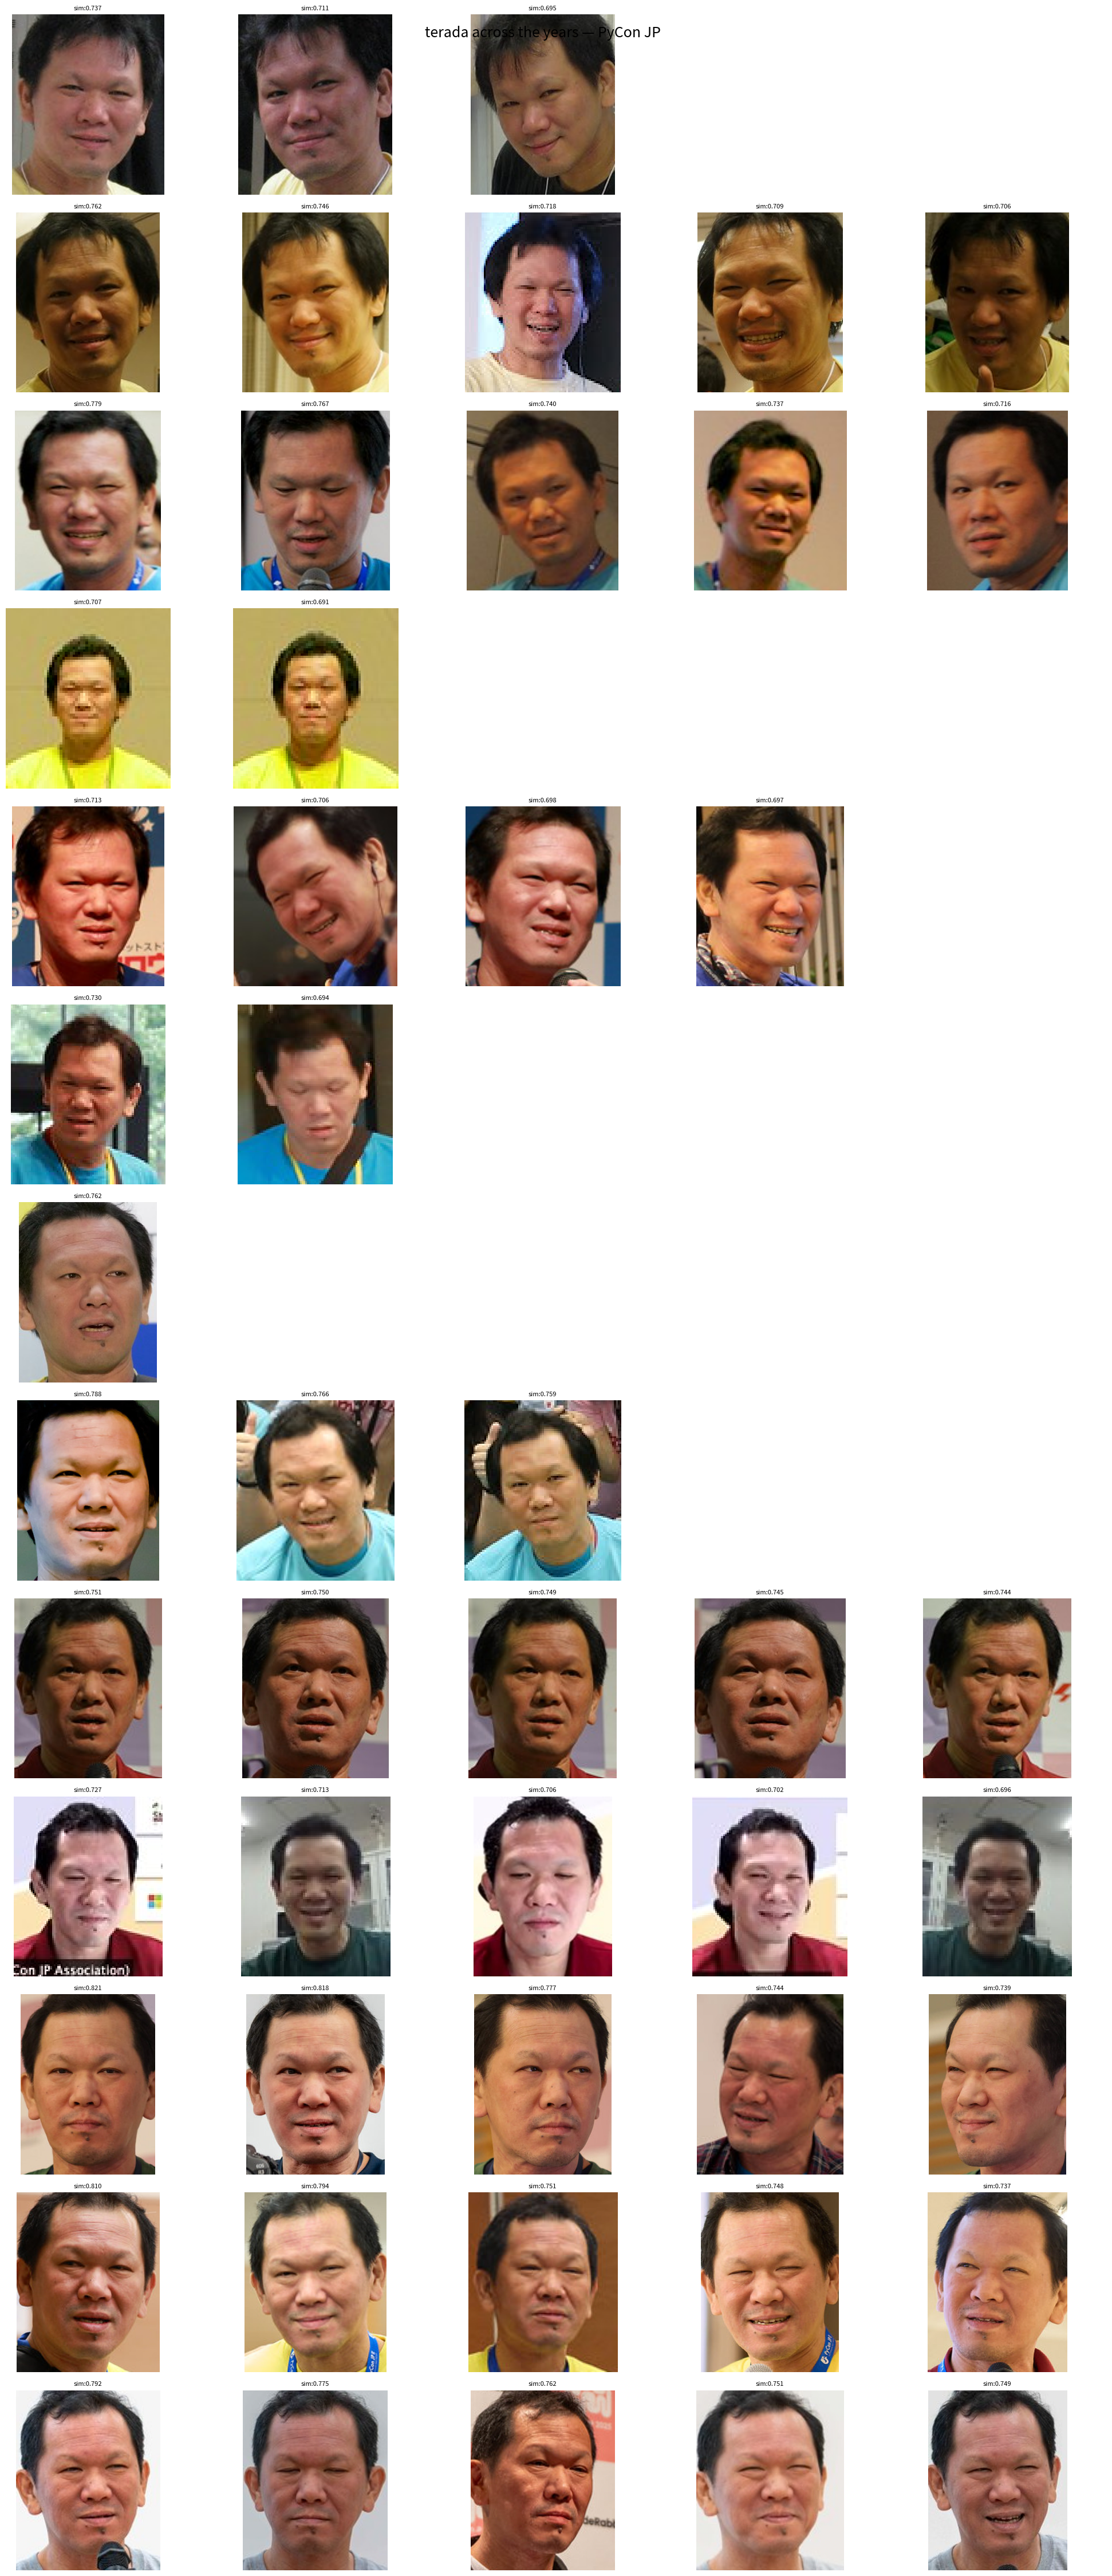

In [11]:
# 年代別のマッチ結果を表示（Top-5/年）
years = sorted(results["year"].dropna().unique())

if len(years) > 0:
    fig, axes = plt.subplots(len(years), 5, figsize=(20, 3.5 * len(years)))
    if len(years) == 1:
        axes = axes.reshape(1, -1)

    for y_idx, year in enumerate(years):
        year_results = results[results["year"] == year].head(5)

        for f_idx in range(5):
            ax = axes[y_idx][f_idx]
            if f_idx < len(year_results):
                row = year_results.iloc[f_idx]
                face_crop = crop_face_from_id(conn, row["face_id"])
                if face_crop is not None:
                    ax.imshow(face_crop)
                    ax.set_title(f"sim:{row['similarity']:.3f}", fontsize=8)
                else:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")

        axes[y_idx][0].set_ylabel(f"{int(year)}", fontsize=14, rotation=0, labelpad=40, va="center")

    plt.suptitle("terada across the years — PyCon JP", fontsize=18)
    plt.tight_layout()
    plt.show()

## 検索速度ベンチマーク

検索レイテンシ (75162 顔ベクトル):
  平均: 22.2 ms
  中央値: 21.7 ms
  最小: 21.4 ms
  最大: 24.3 ms


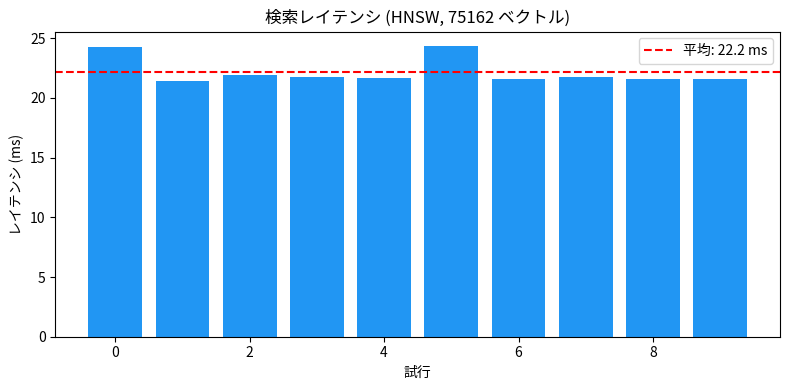

In [12]:
# 複数回検索して速度を計測
latencies = []

for _ in range(10):
    start = time.time()
    conn.execute(f"""
        SELECT f.face_id,
               array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        ORDER BY distance
        LIMIT 20
    """, [[float(x) for x in terada_emb]]).fetchall()
    latencies.append(time.time() - start)

print(f"検索レイテンシ ({total} 顔ベクトル):")
print(f"  平均: {np.mean(latencies)*1000:.1f} ms")
print(f"  中央値: {np.median(latencies)*1000:.1f} ms")
print(f"  最小: {np.min(latencies)*1000:.1f} ms")
print(f"  最大: {np.max(latencies)*1000:.1f} ms")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(latencies)), [l * 1000 for l in latencies], color="#2196F3")
ax.axhline(np.mean(latencies) * 1000, color="red", linestyle="--",
           label=f"平均: {np.mean(latencies)*1000:.1f} ms")
ax.set_title(f"検索レイテンシ (HNSW, {total} ベクトル)")
ax.set_xlabel("試行")
ax.set_ylabel("レイテンシ (ms)")
ax.legend()
plt.tight_layout()
plt.show()

## まとめ

### 実施内容
- pyconjp アーカイブ 23,628枚から顔検出 + Embedding 抽出
- terada の年代別検索により、PyCon JP の歴史を通じた人物追跡を実証
- HNSW インデックスの大規模データでのスケーラビリティを確認

### 次のステップ
- **Notebook 58**: 全実験結果の総合まとめ

In [13]:
conn.close()
print("完了")

完了
